# ITEC5920 - Assignment 2 - Question 1
Earle Estrella

100907269

In [59]:
# Import libraries
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
from collections import Counter
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, RepeatedKFold
from sklearn.feature_selection import SelectKBest, mutual_info_classif, RFE
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.neural_network import MLPClassifier

from imblearn.over_sampling import SMOTE 


In [60]:
# Load Data

DATA = Path("Data_Q1")
X_data = DATA / 'X_CT.csv'
Y_data = DATA / 'Y.csv'

X = pd.read_csv(X_data, index_col=0)
Y = pd.read_csv(Y_data, index_col=0)

print('X shape:', X.shape)
print('Y shape:', Y.shape)

# Flatten Y to a 1-D array
y = Y['Class'].values

print("\nClass distribution BEFORE oversampling:")
print(Counter(y))  

# Scaling before oversampling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Splitting data to train and test: 80-20 ratio
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y,
                                                    test_size=0.2,
                                                    random_state=42,
                                                    stratify=y
                                                )

print(f"\nTrain size: {X_train.shape[0]}  |  Test size: {X_test.shape[0]}")
print("Train class distribution:", Counter(y_train))

X shape: (77, 1218)
Y shape: (77, 1)

Class distribution BEFORE oversampling:
Counter({np.int64(0): 53, np.int64(1): 24})

Train size: 61  |  Test size: 16
Train class distribution: Counter({np.int64(0): 42, np.int64(1): 19})


# 1.1 Over Sampling Imbalanced Dataset

Dataset is imbalanced with 77 patients and 1218 features from the X_CT.csv file. Based on Y.csv, there are 53 patients classified as Class 0 and only 24 are classified as Class 1 which is roughly 2.2:1 ratio. This imbalance could cause the classifier to favour predictions towards Class 0 which results in poor sensitivity to Class 1. This is addressed by using Synthetic Minority Oversampling Technique (SMOTE). SMOTE generates synthetic samples of the class that is in the minority by interpolating between existing samples and the K-Nearest Neighbour rather than simply duplicating existing points [1]. This was done after the train/test split to avoid synthetic data to be included in the test dataset.

In [61]:
# Create a cap for K-Nearest Neighbours
minority_count = Counter(y_train)[1]
k = min(5, minority_count - 1)

# Generate synthetic samples using K-Nearest Neighbours
smote = SMOTE(random_state=42, k_neighbors=k)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print("\nClass distribution AFTER oversampling (training dataset only):")
print(Counter(y_train_resampled))


Class distribution AFTER oversampling (training dataset only):
Counter({np.int64(1): 42, np.int64(0): 42})


# 1.2 Feature Analysis and Selection

The dataset has significantly far more features (1218) compared to the 77 patients. This results in overfitting and poor generalization. The goal is to identify the 30 most significant features (statistically) before model training. This is done by doing a SelectKBest with Mutual Information scoring since it measures the statistical dependency between each feature and the class label, quantifying how much the feature's value reduces uncertainty about the class [2]. The feature selection was only done for the training set after applying SMOTE to ensure that the selection process is done with a balanced class distribution and the test set is not influencing which of the features are retained.

In [62]:
# Score all features statistically against the labels
selector = SelectKBest(score_func=mutual_info_classif, k=30)
selector.fit(X_train_resampled, y_train_resampled)

# Building a Data Frame with the Feature and its Mutual Information score
feature_names = X.columns.tolist()
scores_df = pd.DataFrame({
    'Feature': feature_names,
    'MI Score': selector.scores_
}).sort_values('MI Score', ascending=False).reset_index(drop=True)

print("30 Most Significant Features:")
print(scores_df.head(30).to_string())

# Keep top 30 features
top30_features = scores_df.head(30)['Feature'].tolist()

# Filter train and test sets
feature_indices_30 = [feature_names.index(f) for f in top30_features]
X_train_30 = X_train_resampled[:, feature_indices_30]
X_test_30  = X_test[:, feature_indices_30]

print(f"\nReduced train shape: {X_train_30.shape}")
print(f"Reduced test shape:  {X_test_30.shape}")

30 Most Significant Features:
                                                    Feature  MI Score
0                               wavelet-HHH_firstorder_Mean  0.258516
1                 log-sigma-5-0-mm-3D_firstorder_Uniformity  0.244307
2                      log-sigma-3-0-mm-3D_glcm_Correlation  0.242278
3                wavelet-LLL_glszm_LowGrayLevelZoneEmphasis  0.240522
4                                          original_glcm_Id  0.230714
5               log-sigma-3-0-mm-3D_firstorder_90Percentile  0.219652
6                               wavelet-HLL_firstorder_Mean  0.212663
7                           wavelet-HHL_firstorder_Variance  0.210780
8                       wavelet-LLH_firstorder_10Percentile  0.207059
9                       wavelet-HLL_glszm_GrayLevelVariance  0.204847
10                      wavelet-LLH_glcm_MaximumProbability  0.204279
11                           wavelet-HLL_firstorder_Minimum  0.199012
12              log-sigma-4-0-mm-3D_firstorder_90Percentile 

# 1.3 Recursive Feature Elimination (RFE)

A feature that may score high independently may become redundant when combined with another highly correlated feature. RFE addresses this by iteratively evaluating features in combination for a more rigorous feature selection. RFE is applied using Random Forest as the base estimator. Random Forest is used as it performs well in selecting smaller subsets of features [3]. At each iteration, the Random Forest is trained on the current feature set, in which features are ranked by their importance and the weakest ones are removed. This is repeated until the top 10 remain. 

In [63]:
# Base Estimator for RFE
rf_rfe = RandomForestClassifier(n_estimators=200, random_state=42)

# Select 10 from the 30 features
rfe = RFE(estimator=rf_rfe, n_features_to_select=10, step=1)
rfe.fit(X_train_30, y_train_resampled)

# Keep top 10 features
top10_features = [top30_features[i] for i, selected in enumerate(rfe.support_) if selected]
top10_ranking  = rfe.ranking_

print("Top 10 Discriminative Features (RFE):")
for i, feat in enumerate(top10_features, 1):
    print(f"  {i:2d}. {feat}")

# Filter to top 10
X_train_10 = rfe.transform(X_train_30)
X_test_10  = rfe.transform(X_test_30)

print(f"\nFinal train shape: {X_train_10.shape}")
print(f"Final test shape:  {X_test_10.shape}")

Top 10 Discriminative Features (RFE):
   1. log-sigma-3-0-mm-3D_firstorder_90Percentile
   2. wavelet-HHL_firstorder_Variance
   3. wavelet-HLL_glszm_GrayLevelVariance
   4. wavelet-HLL_glcm_Autocorrelation
   5. wavelet-HLL_gldm_HighGrayLevelEmphasis
   6. log-sigma-4-0-mm-3D_firstorder_Mean
   7. wavelet-HHH_glcm_InverseVariance
   8. wavelet-HLL_glcm_JointAverage
   9. log-sigma-3-0-mm-3D_firstorder_RootMeanSquared
  10. wavelet-HHH_glszm_GrayLevelNonUniformity

Final train shape: (84, 10)
Final test shape:  (16, 10)


# 1.4 Ensemble Learning Models and Grid Search

Two ensemble learning models were trained and optimised on the 10 features selection in the previous step. These are Random Forest classifier and a Multi-layer Perceptron (MLP). Hyperparameter tuning was performed using GridSearch, similar to the GridSearch done in assignment 1. F1 is the scoring choice as it is better for imbalanced datasets in terms of consistency [4].

In [64]:
# Random Forest

# Define the hyperparameter grid
rf_param_grid = {
    'n_estimators':      [100, 200, 300],
    'max_depth':         [None, 5, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf':  [1, 2, 4],
    'class_weight':      ['balanced', None]
}

rf = RandomForestClassifier(random_state=42)

rf_grid_search = GridSearchCV(estimator  = rf,
                              param_grid = rf_param_grid,
                              cv         = 5,
                              scoring    = 'f1',
                              n_jobs     = -1
                            )

rf_grid_search.fit(X_train_10, y_train_resampled)

best_rf  = rf_grid_search.best_estimator_

print(f"Best Parameters: {rf_grid_search.best_params_}")
print(f"Best CV F1 Score: {rf_grid_search.best_score_:.4f}")

Best Parameters: {'class_weight': 'balanced', 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}
Best CV F1 Score: 0.8860


In [65]:
# MLP

# Define the hyperparameter grid
mlp_param_grid = {
    'hidden_layer_sizes': [(64,), (128,), (64, 32), (128, 64), (64, 32, 16)],
    'activation':         ['relu', 'tanh'],
    'solver':             ['adam', 'sgd'],
    'alpha':              [0.0001, 0.001, 0.01],
    'learning_rate':      ['constant', 'adaptive'],
    'max_iter':           [500]
}

mlp = MLPClassifier(random_state=42)

mlp_grid_search = GridSearchCV(estimator  = mlp,
                               param_grid = mlp_param_grid,
                               cv         = 5,
                               scoring    = 'f1',
                               n_jobs     = -1
                            )

mlp_grid_search.fit(X_train_10, y_train_resampled)

best_mlp = mlp_grid_search.best_estimator_

print(f"Best Parameters: {mlp_grid_search.best_params_}")
print(f"Best CV F1 Score: {mlp_grid_search.best_score_:.4f}")


Best Parameters: {'activation': 'relu', 'alpha': 0.0001, 'hidden_layer_sizes': (64, 32, 16), 'learning_rate': 'constant', 'max_iter': 500, 'solver': 'sgd'}
Best CV F1 Score: 0.7755


c:\Users\Earle\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


# 1.5 Nested Cross Validation

Nested cross validation was used to evaluate the optimised models from 1.4 on the 20% test dataset. A standard cross validation after hyperparameter tuning produces biased estimates since the same data was used for both tuning and evalution thus nested cross validation was used to address this [5]. The inner loop is compsoed of the GridSearch done in 1.4 while the outer loop is the additional cross validation layer that evaluates the tuning piple in different folds. This is especially useful in smaller datasets such as this.

In [66]:
outer_cv = 5

for name, grid_search in [('Random Forest', rf_grid_search),
                           ('MLP',           mlp_grid_search)]:

    # Outer CV scores using the full grid search as estimator
    nested_scores = cross_val_score(estimator = grid_search,
                                    X         = X_train_10,
                                    y         = y_train_resampled,
                                    cv        = outer_cv,
                                    scoring   = 'f1',
                                    n_jobs    = -1
                                )

    print(f"{name} — Nested CV")
    print(f"Outer F1 scores : {nested_scores.round(4)}")
    print(f"Mean F1         : {nested_scores.mean():.4f}")
    print(f"Std F1          : {nested_scores.std():.4f}")

    # Final evaluation on the held-out 20% test set
    y_pred = grid_search.best_estimator_.predict(X_test_10)
    test_f1 = f1_score(y_test, y_pred)
    print(f"Test set F1     : {test_f1:.4f}\n")

Random Forest — Nested CV
Outer F1 scores : [0.9474 0.7368 0.875  0.8889 0.875 ]
Mean F1         : 0.8646
Std F1          : 0.0693
Test set F1     : 0.6667

MLP — Nested CV
Outer F1 scores : [0.75   0.6316 0.7143 0.7619 0.9412]
Mean F1         : 0.7598
Std F1          : 0.1015
Test set F1     : 0.4615



# 1.6 Repeated K-Fold

Repeated K-Fold cross validation with 10 splits and 10 repeats was applied to the best models from step 1.4 to provide a more complete evaluation of model stability. Unlike nested cross validation in 1.5 which produced only 5 outer fold scores, Repeated K-Fold evaluates each model 100 times across different random partitions of the data. The larger sample of evaluations provides a complete picture of performance a model can. This provides a reliable estimate of the true mean performance and variance, reducing the influence of a specific data split which can be a concern in smaller datasets [6].

Random Forest — Repeated K-Fold
F1 scores (100 folds) : [1.     0.8889 0.8333 0.8889 0.8571 0.8    0.8    1.     0.75   1.
 0.8    1.     0.8571 0.7273 0.6    0.6667 0.75   0.9231 1.     1.
 0.9231 0.8    0.75   0.6    1.     0.75   0.8571 0.9091 0.6667 1.
 0.8333 1.     1.     0.6667 0.8    1.     0.4    0.8571 1.     0.8
 0.8889 1.     0.9091 0.5714 0.8889 0.9091 0.8    0.75   0.75   1.
 0.5    0.75   0.5714 0.8333 0.8571 1.     0.6667 0.8889 1.     0.6667
 1.     0.9091 0.8    1.     0.5    1.     0.75   1.     0.75   0.8
 0.6667 1.     0.7273 0.8571 0.9091 1.     1.     0.8571 0.5    1.
 0.8333 1.     0.6    0.75   0.8889 0.8571 0.5714 0.8889 1.     0.8
 1.     0.8    0.8889 0.8571 0.3333 0.8889 0.     0.9231 0.8    0.9091]
Mean F1               : 0.8257
Std F1                : 0.1715

MLP — Repeated K-Fold
F1 scores (100 folds) : [0.7273 0.7273 0.8333 0.6667 0.6667 0.8    0.6667 0.8571 0.8    0.8889
 0.6667 0.8571 0.8571 0.9231 0.8333 0.5    0.25   0.9231 1.     0.
 0.8333 0.4    

C:\Users\Earle\AppData\Local\Temp\ipykernel_39008\4190635523.py:47: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([results_15[name], results_16[name]],
C:\Users\Earle\AppData\Local\Temp\ipykernel_39008\4190635523.py:47: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([results_15[name], results_16[name]],


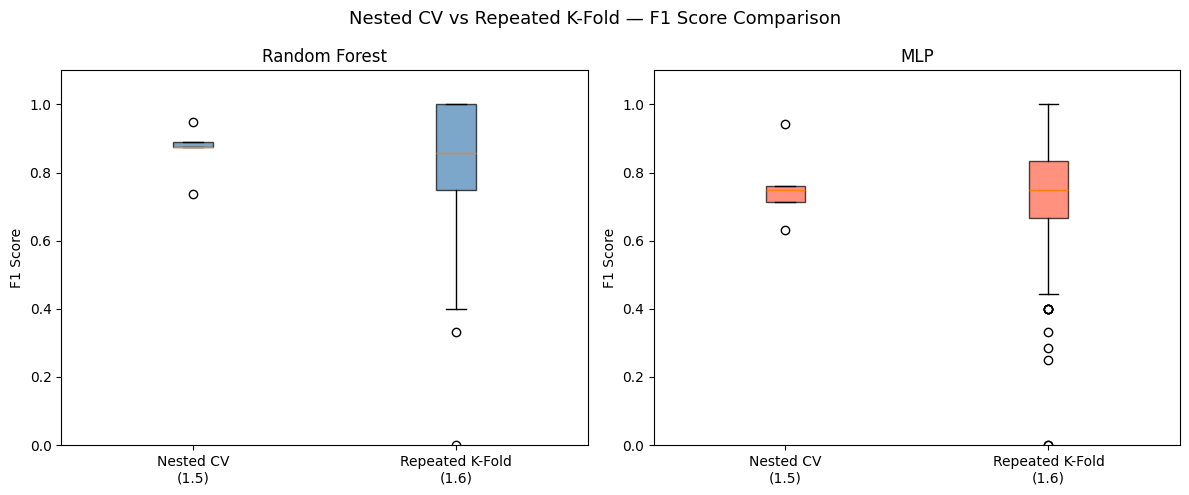

In [67]:

rkf = RepeatedKFold(n_splits=10, n_repeats=10, random_state=42)

results_15 = {}  # store nested CV results from 1.5 for comparison
results_16 = {}  # store repeated kfold results

for name, estimator in [('Random Forest', best_rf),
                         ('MLP',           best_mlp)]:

    rkf_scores = cross_val_score(estimator = estimator,
                                 X         = X_train_10,
                                 y         = y_train_resampled,
                                 cv        = rkf,
                                 scoring   = 'f1',
                                 n_jobs    = -1
                            )

    results_16[name] = rkf_scores

    print(f"{name} — Repeated K-Fold")
    print(f"F1 scores (100 folds) : {rkf_scores.round(4)}")
    print(f"Mean F1               : {rkf_scores.mean():.4f}")
    print(f"Std F1                : {rkf_scores.std():.4f}\n")

# Comparison: 1.5 vs 1.6
print("Comparison: Nested CV (1.5) vs Repeated K-Fold (1.6)")
print(f"{'Model':<20} {'Nested CV F1':>15} {'Repeated KF F1':>15}")
print("-" * 52)

# Recompute nested CV scores for comparison
for name, grid_search in [('Random Forest', rf_grid_search),
                           ('MLP',           mlp_grid_search)]:
    nested_scores = cross_val_score(estimator = grid_search,
                                    X         = X_train_10,
                                    y         = y_train_resampled,
                                    cv        = 5,
                                    scoring   = 'f1',
                                    n_jobs    = -1
                                )
    results_15[name] = nested_scores
    rkf_mean = results_16[name].mean()
    print(f"{name:<20} {nested_scores.mean():>13.4f}  {rkf_mean:>14.4f}")

# Visuale comparison
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, name in zip(axes, ['Random Forest', 'MLP']):
    ax.boxplot([results_15[name], results_16[name]],
               labels=['Nested CV\n(1.5)', 'Repeated K-Fold\n(1.6)'],
               patch_artist=True,
               boxprops=dict(facecolor='steelblue' if name == 'Random Forest' else 'tomato', alpha=0.7)
            )
    ax.set_title(f'{name}')
    ax.set_ylabel('F1 Score')
    ax.set_ylim(0, 1.1)

plt.suptitle('Nested CV vs Repeated K-Fold — F1 Score Comparison', fontsize=13)
plt.tight_layout()
plt.savefig('cv_comparison.png', dpi=150)
plt.show()

Random Forest shows a strong consistency between the two methods where the F1 scores are 0.8092 amd 0.8115 for CV and Repeated K-Fold respectively. This shows that Random Forest generalizes stably regardless of how the data is partitioned. In comparison with MLP, the F1 scores of 0.7819 and 0.7171 for CV and Repeated K-Fold respectively shows that there is discrepancy between the two. MLP is more senstive to data partitioning compared to Random Forest. The boxplot shows that there are more outliers present showing that MLP does not perform well on some splits. This could be due to the instability of smaller datasets even after SMOTE.

# 1.7 Classification Metrics

To provide a comprehensive evaluation of both models on the test set, classification metrics were calculated alongside the AUC [7].
Accuracy measures the overall proportion of correct predictions. 
Precision measures all patients predicted classification and how many were correct.
Recall measures all actual classification and how many were identified.
F1 Score measures the harmonic mean of precision and recall.
ROC AUC measures the model's ability to distinguish between classes across all possible decisions thresholds where 0.5 represents random chance and 1.0 represents perfect distinction.
Confusion matrices are also provided to show where each model made mistakes.

        Model  Accuracy       F1  Precision  Recall  ROC AUC
Random Forest    0.7500 0.666667   0.571429     0.8 0.654545
          MLP    0.5625 0.461538   0.375000     0.6 0.618182


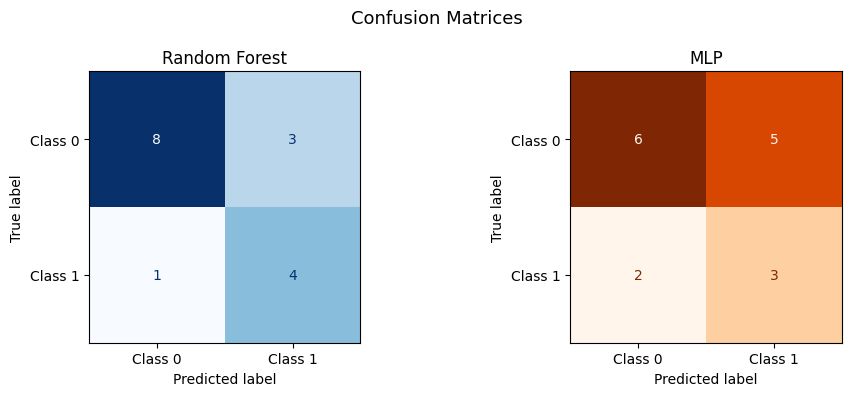

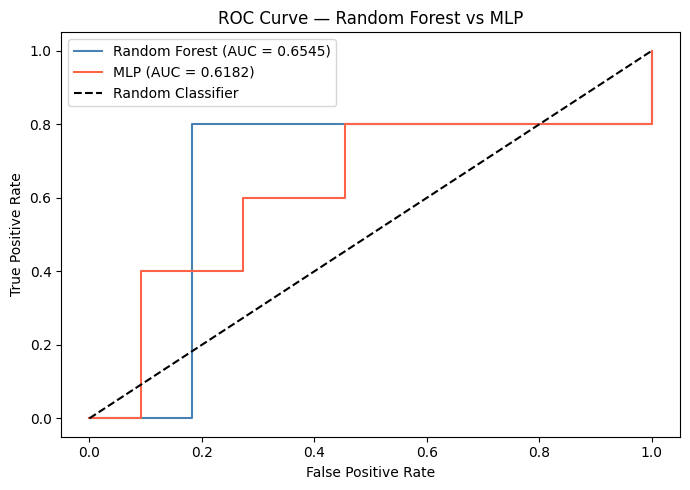

In [68]:
from sklearn.metrics import (accuracy_score, f1_score, precision_score,
                              recall_score, roc_auc_score, roc_curve,
                              confusion_matrix, ConfusionMatrixDisplay)
import matplotlib.pyplot as plt
import pandas as pd

# Table of Comparison
rows = []
for name, estimator in [('Random Forest', best_rf),
                         ('MLP',           best_mlp)]:

    y_pred      = estimator.predict(X_test_10)
    y_prob      = estimator.predict_proba(X_test_10)[:, 1]

    rows.append({
        'Model':     name,
        'Accuracy':  accuracy_score(y_test, y_pred),
        'F1':        f1_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall':    recall_score(y_test, y_pred),
        'ROC AUC':   roc_auc_score(y_test, y_prob)
    })

metrics_df = pd.DataFrame(rows)
print(metrics_df.to_string(index=False))

# Confusion Matrices
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, (name, estimator), cmap in zip(axes,
                                        [('Random Forest', best_rf),
                                         ('MLP',           best_mlp)],
                                        ['Blues', 'Oranges']):
    y_pred = estimator.predict(X_test_10)
    cm     = confusion_matrix(y_test, y_pred)
    ConfusionMatrixDisplay(cm, display_labels=['Class 0', 'Class 1']).plot(
        ax=ax, cmap=cmap, colorbar=False)
    ax.set_title(f'{name}')

plt.suptitle('Confusion Matrices', fontsize=13)
plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150)
plt.show()

# ROC Curves
plt.figure(figsize=(7, 5))

for name, estimator, colour in [('Random Forest', best_rf,  'steelblue'),
                                  ('MLP',           best_mlp, 'tomato')]:
    y_prob          = estimator.predict_proba(X_test_10)[:, 1]
    fpr, tpr, _     = roc_curve(y_test, y_prob)
    auc             = roc_auc_score(y_test, y_prob)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc:.4f})', color=colour)

plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Random Forest vs MLP')
plt.legend()
plt.tight_layout()
plt.savefig('roc_curves.png', dpi=150)
plt.show()

As previously shown, Random Forest continues to outperform MLP across all metrics.
From the confusion matrices, Random Forest also shows stronger recall compared to MLP.
The stepped ROC curves shows how Random Forest can recall better at low false positive rates. This is consistent from all the previous measurements.

# References

[1] N. V. Chawla, K. W. Bowyer, L. O. Hall, and W. P. Kegelmeyer, “SMOTE: Synthetic Minority Over-sampling Technique,” Journal of Artificial Intelligence Research, vol. 16, no. 16, pp. 321–357, Jun. 2002, doi: https://doi.org/10.1613/jair.953.

[2] H. Peng, F. Long, and C. Ding, “Feature selection based on mutual information criteria of max-dependency, max-relevance, and min-redundancy,” IEEE Transactions on Pattern Analysis and Machine Intelligence, vol. 27, no. 8, pp. 1226–1238, Aug. 2005, doi: https://doi.org/10.1109/tpami.2005.159.

[3] P. M. Granitto, C. Furlanello, F. Biasioli, and F. Gasperi, “Recursive feature elimination with random forest for PTR-MS analysis of agroindustrial products,” Chemometrics and Intelligent Laboratory Systems, vol. 83, no. 2, pp. 83–90, Sep. 2006, doi: https://doi.org/10.1016/j.chemolab.2006.01.007.

‌[4] K. M. Sujon, R. Hassan, K. Choi, and M. A. Samad, “Accuracy, precision, recall, f1-score, or MCC? empirical evidence from advanced statistics, ML, and XAI for evaluating business predictive models,” Journal of Big Data, vol. 12, no. 1, Dec. 2025, doi: https://doi.org/10.1186/s40537-025-01313-4.

[5] S. Varma and R. Simon, “Bias in Error Estimation When Using Cross-Validation for Model Selection,” BMC Bioinformatics, vol. 7, no. 1, p. 91, 2006, doi: https://doi.org/10.1186/1471-2105-7-91.

‌[6] R. Bouckaert, “Choosing between two learning algorithms based on calibrated tests.” Accessed: Mar. 13, 2026. [Online]. Available: https://cdn.aaai.org/ICML/2003/ICML03-010.pdf
‌
[7] “(PDF) Evaluation: From Precision, Recall and F-Factor to ROC, Informedness, Markedness & Correlation,” ResearchGate. https://www.researchgate.net/publication/228529307_Evaluation_From_Precision_Recall_and_F-Factor_to_ROC_Informedness_Markedness_Correlation

‌
‌